In [1]:
# Import necessary libraries
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Define transformation to convert images to PyTorch tensors
tensor_transform = transforms.ToTensor()

# Download and load MNIST training data
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=tensor_transform)

# DataLoader for batching and shuffling
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 28.1MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 46.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.28MB/s]


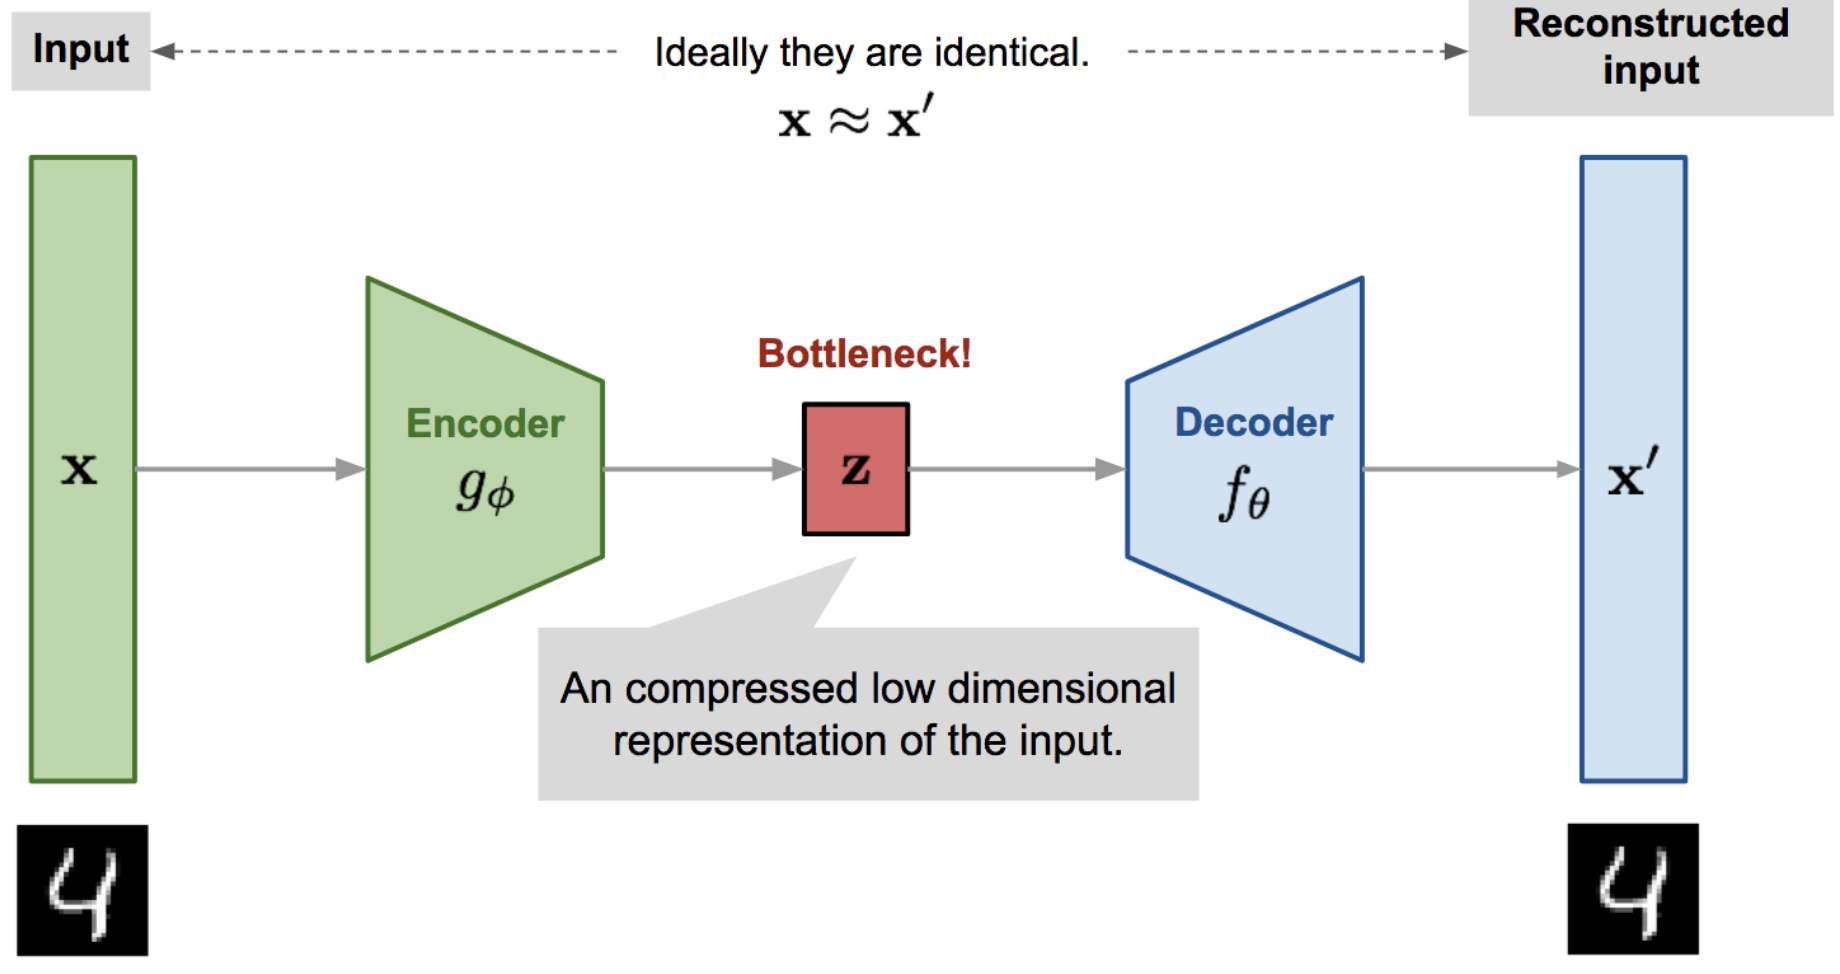

In [3]:
import torch
from torch import nn

# Define the Variational Autoencoder (VAE) class
class VAE(nn.Module):
    def __init__(self, latent_dim=9):
        super(VAE, self).__init__()

        # Encoder: Reduces input dimension to latent space representation
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),   # First hidden layer (784 → 128 neurons)
            nn.ReLU(),
            nn.Linear(128, 64),        # Second hidden layer (128 → 64 neurons)
            nn.ReLU()
        )

        # Encoder outputs two vectors:
        # - Mean vector (mu) of latent distribution
        # - Log-variance vector (logvar) of latent distribution
        self.fc_mu = nn.Linear(64, latent_dim)       # Outputs mean (μ)
        self.fc_logvar = nn.Linear(64, latent_dim)   # Outputs log variance (log σ²)

        # Decoder: Expands latent representation back to original input dimension
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),   # Latent → hidden layer (9 → 64 neurons)
            nn.ReLU(),
            nn.Linear(64, 128),          # Hidden layer (64 → 128 neurons)
            nn.ReLU(),
            nn.Linear(128, 28 * 28),     # Output layer reconstructing image (128 → 784 neurons)
            nn.Sigmoid()                 # Outputs values between 0 and 1
        )

    # The reparameterization trick (crucial for training a VAE)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)        # Compute standard deviation from log variance
        eps = torch.randn_like(std)          # Sample random noise ε from N(0, I) ! IT IS  a vector of latent_dim independent noise !!!
        return mu + eps * std               # Return sampled latent vector z

    # Forward pass clearly defined
    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)             # Get mean from encoder output
        logvar = self.fc_logvar(encoded)     # Get log-variance from encoder output
        z = self.reparameterize(mu, logvar)  # Sample z from latent distribution
        reconstructed = self.decoder(z)      # Reconstruct input from latent vector z
        return reconstructed, mu, logvar


In [4]:
# Instantiate your model
model = VAE(latent_dim=16)

# Total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 221,360
Trainable parameters: 221,360


In [5]:
from torchsummary import summary

# If using an image input, flatten to 784 (28x28)
summary(model, input_size=(28 * 28,))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 128]         100,480
              ReLU-2                  [-1, 128]               0
            Linear-3                   [-1, 64]           8,256
              ReLU-4                   [-1, 64]               0
            Linear-5                   [-1, 16]           1,040
            Linear-6                   [-1, 16]           1,040
            Linear-7                   [-1, 64]           1,088
              ReLU-8                   [-1, 64]               0
            Linear-9                  [-1, 128]           8,320
             ReLU-10                  [-1, 128]               0
           Linear-11                  [-1, 784]         101,136
          Sigmoid-12                  [-1, 784]               0
Total params: 221,360
Trainable params: 221,360
Non-trainable params: 0
-------------------------------

**[nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')](https://pytorch.org/docs/stable/generated/torch.nn.functional.binary_cross_entropy.html )** computes the Binary Cross-Entropy (BCE) loss between the reconstructed image recon_x and the original image x. It measures how well the decoder’s output matches the true input pixel-wise, treating each pixel as a Bernoulli-distributed probability.

- recon_x: Reconstructed image (values between 0 and 1 due to Sigmoid()).
- x: Original image (also scaled between 0 and 1).
- reduction='sum': The total BCE loss is summed over all pixels and batches to match the scale of the KL divergence term.


This loss function ensures that the decoder learns to generate realistic images by minimizing the difference between the true and reconstructed pixel distributions. BCE is preferred over Mean Squared Error (MSE) for binary-like images (e.g., MNIST) as it produces sharper reconstructions.

In [6]:
def loss_function(recon_x, x, mu, logvar):
    """
    Computes the ELBO loss for VAE training.

    Parameters:
    - recon_x: Reconstructed images (output of decoder)
    - x: Original images
    - mu: Mean vector from encoder
    - logvar: Log-variance vector from encoder

    Returns:
    - ELBO Loss (Reconstruction Loss + KL Divergence)
    """

    # 1. Reconstruction Loss: Binary Cross Entropy (BCE) for pixel-wise difference
    #https://pytorch.org/docs/stable/generated/torch.nn.functional.binary_cross_entropy.html

    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence: Measure how close q(z|x) is to the prior p(z)

    KL = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total ELBO loss (we want to MINIMIZE it)
    return BCE + KL


Training Loop.......

In [ ]:
import torch
import datetime
import os

# Check if GPU is available, else use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model and move it to the device
latent_dim = 16  # Define latent space dimension
model = VAE(latent_dim).to(device)

# Define optimizer (Adam optimizer)

# for a very nice intro to backpropagation: https://youtu.be/VMj-3S1tku0?si=pzQ6lxsRmHDX2hM7

optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Maximum number of epochs
max_epochs = 40
# Early stopping configuration
patience = 5  # Stop after 5 epochs without improvement
min_delta = 0.001  # Minimum change in loss to qualify as improvement

# Variables to track best loss and early stopping
best_loss = float('inf')
epochs_no_improve = 0

In [ ]:


# Training Loop
for epoch in range(max_epochs):
    train_loss = 0

    for images, _ in loader:
        images = images.view(-1, 28*28).to(device)

        optimizer.zero_grad()
        recon_images, mu, logvar = model(images)
        loss = loss_function(recon_images, images, mu, logvar)

        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    average_loss = train_loss / len(dataset)
    print(f"Epoch {epoch+1}/{max_epochs}, Average Loss: {average_loss:.4f}")

    # Early stopping check
    if best_loss - average_loss > min_delta:
        best_loss = average_loss
        epochs_no_improve = 0  # Reset counter if improvement
    else:
        epochs_no_improve += 1
        print(f"📉 No improvement for {epochs_no_improve} epoch(s)")

    if epochs_no_improve >= patience:
        print(f"🛑 Early stopping triggered after {epoch+1} epochs.")
        break

# Save the model with a smart timestamped name
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
model_name = f"vae_latent{latent_dim}_{timestamp}.pt"
torch.save(model.state_dict(), model_name)
print(f"✅ Model saved as '{model_name}'")


Epoch 1/40, Average Loss: 167.0054
Epoch 2/40, Average Loss: 127.9776
Epoch 3/40, Average Loss: 120.5534
Epoch 4/40, Average Loss: 117.0013
Epoch 5/40, Average Loss: 115.0430
Epoch 6/40, Average Loss: 113.7042
Epoch 7/40, Average Loss: 112.7780
Epoch 8/40, Average Loss: 112.0758
Epoch 9/40, Average Loss: 111.4609
Epoch 10/40, Average Loss: 111.0465
Epoch 11/40, Average Loss: 110.6095
Epoch 12/40, Average Loss: 110.2313
Epoch 13/40, Average Loss: 109.9100
Epoch 14/40, Average Loss: 109.6492
Epoch 15/40, Average Loss: 109.4254
Epoch 16/40, Average Loss: 109.1743
Epoch 17/40, Average Loss: 109.0024
Epoch 18/40, Average Loss: 108.8086
Epoch 19/40, Average Loss: 108.5969
Epoch 20/40, Average Loss: 108.4825
Epoch 21/40, Average Loss: 108.3056
Epoch 22/40, Average Loss: 108.1660
Epoch 23/40, Average Loss: 108.0354
Epoch 24/40, Average Loss: 107.9378
Epoch 25/40, Average Loss: 107.8014
Epoch 26/40, Average Loss: 107.7185
Epoch 27/40, Average Loss: 107.5947
Epoch 28/40, Average Loss: 107.4811
E

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Instantiate the same architecture with the same latent_dim
latent_dim = 16
model = VAE(latent_dim).to(device)

# Load the saved state dictionary
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/Models_24_25/Models/vae_latent16_2025-03-21_14-04.pt", map_location=device))

print("✅ Model loaded successfully.")


✅ Model loaded successfully.


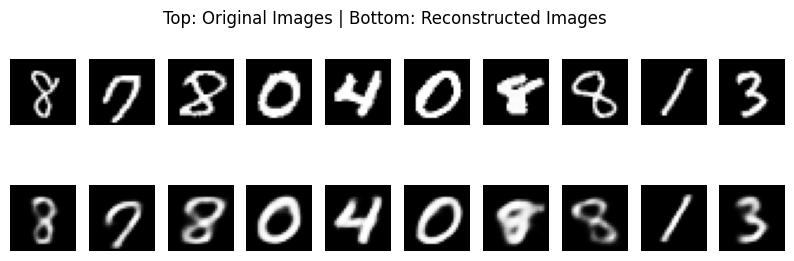

In [ ]:
import matplotlib.pyplot as plt

# Set the model to evaluation mode
model.eval()

# Get a batch of images from the dataset
dataiter = iter(loader)
images, _ = next(dataiter)
images = images.view(-1, 28*28).to(device)

# Forward pass through VAE to get reconstructed images
with torch.no_grad():  # Disable gradient tracking for efficiency
    recon_images, _, _ = model(images)

# Convert tensors to numpy arrays for visualization
images = images.cpu().numpy()
recon_images = recon_images.cpu().numpy()

# Plot original vs. reconstructed images
fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))

for i in range(10):
    # Original images (Top Row)
    axes[0, i].imshow(images[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')

    # Reconstructed images (Bottom Row)
    axes[1, i].imshow(recon_images[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

plt.suptitle("Top: Original Images | Bottom: Reconstructed Images")
plt.show()


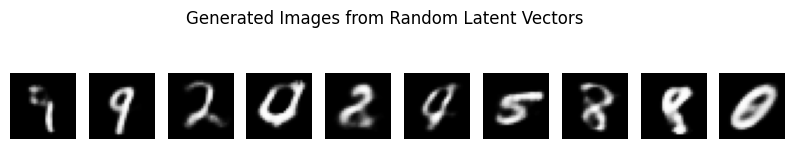

In [ ]:
import torch
import matplotlib.pyplot as plt

# Set the model to evaluation mode
model.eval()

# Sample random latent vectors from a normal distribution
num_samples = 10  # Number of images to generate
random_latent_vectors = torch.randn(num_samples, latent_dim).to(device)  # N(0,1)

# Decode these random latent vectors into images
with torch.no_grad():  # Disable gradient computation
    generated_images = model.decoder(random_latent_vectors)

# Convert tensors to numpy arrays
generated_images = generated_images.cpu().numpy()

# Plot generated images
fig, axes = plt.subplots(nrows=1, ncols=num_samples, figsize=(10, 2))

for i in range(num_samples):
    axes[i].imshow(generated_images[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.suptitle("Generated Images from Random Latent Vectors")
plt.show()


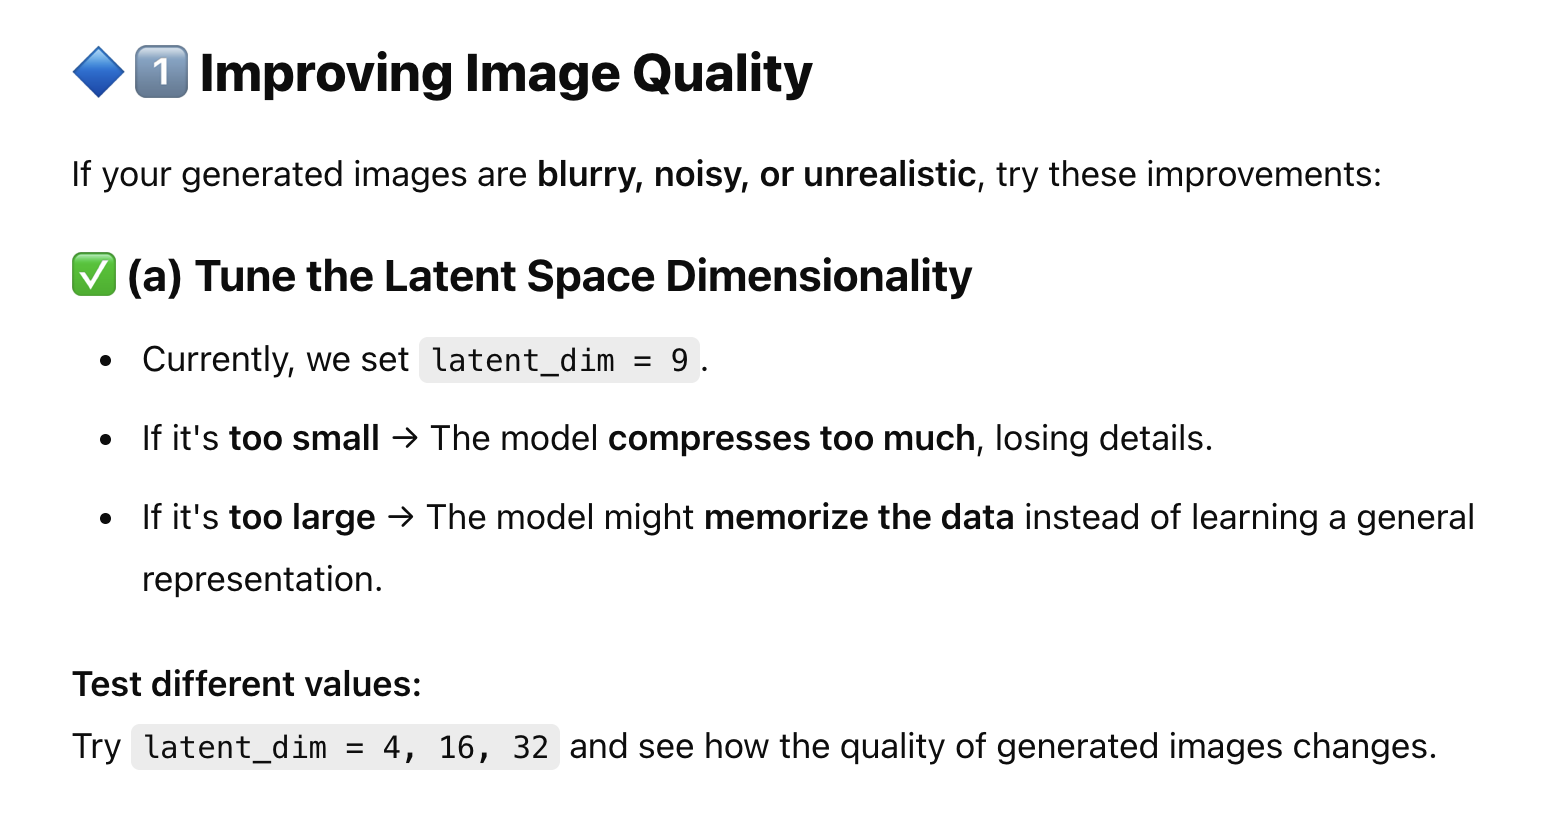



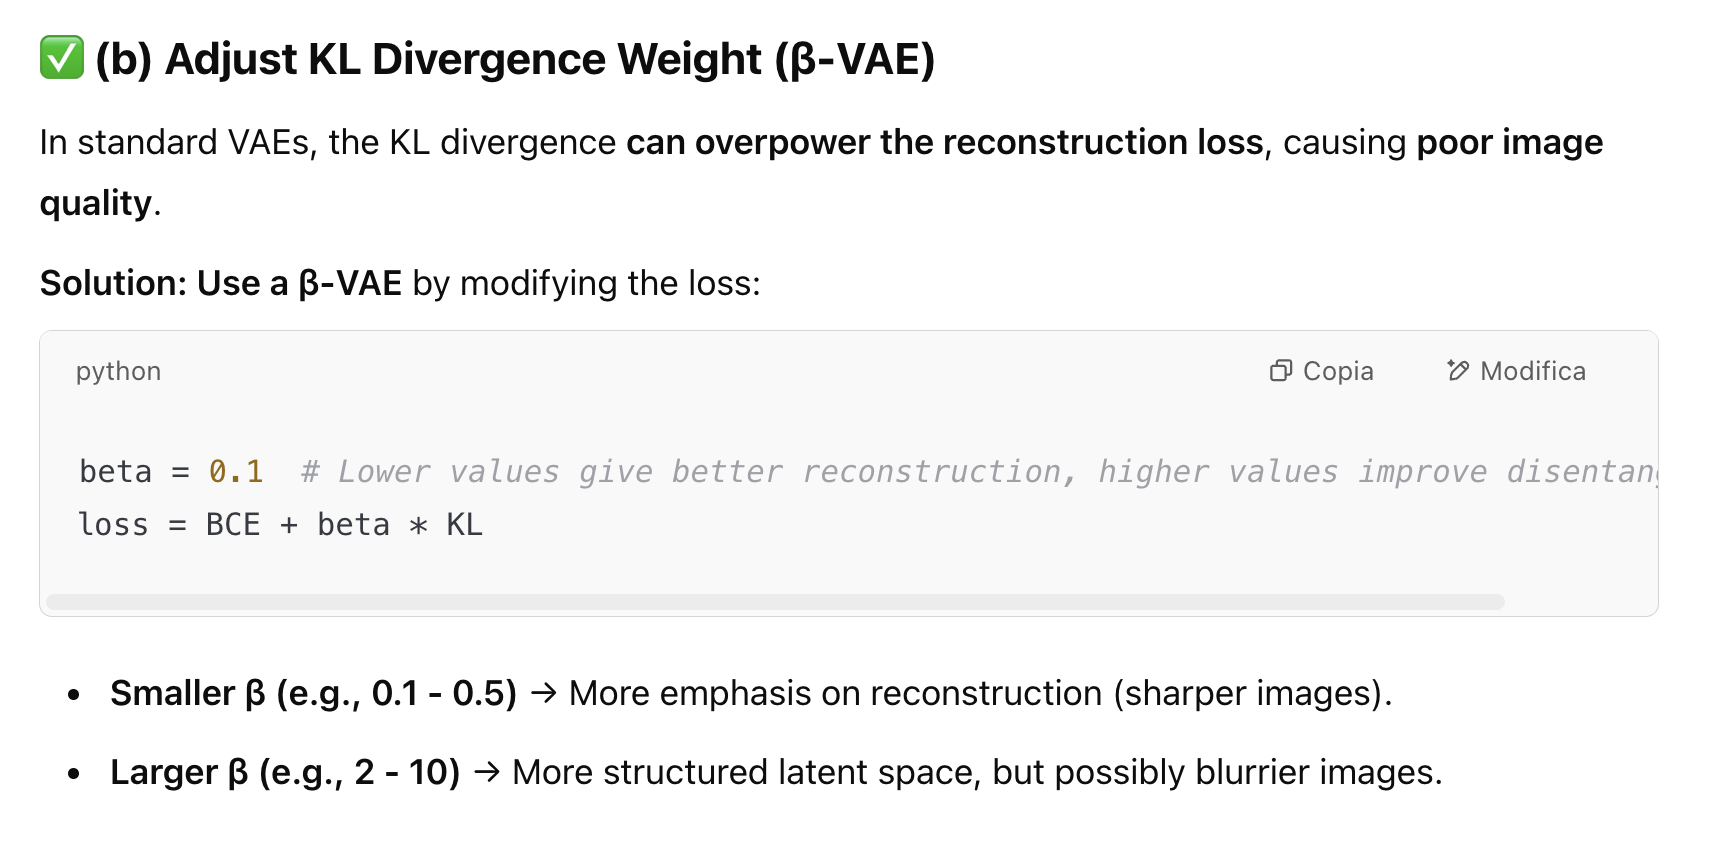

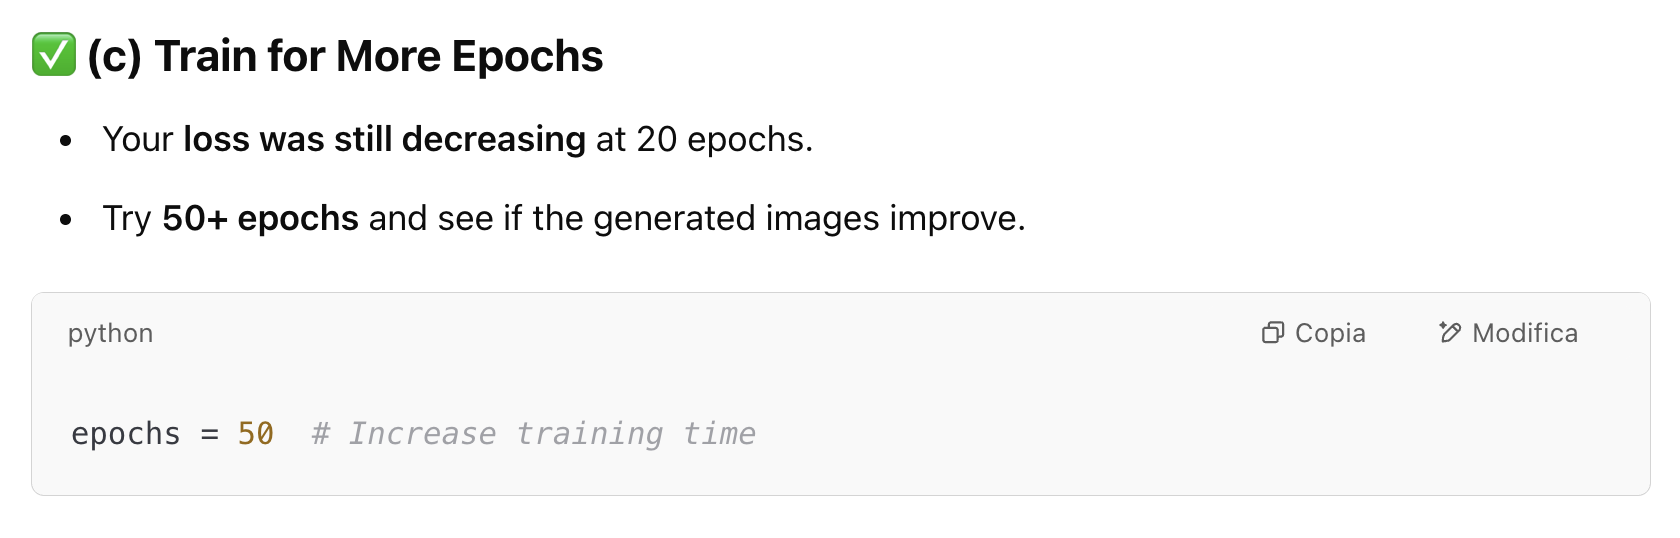

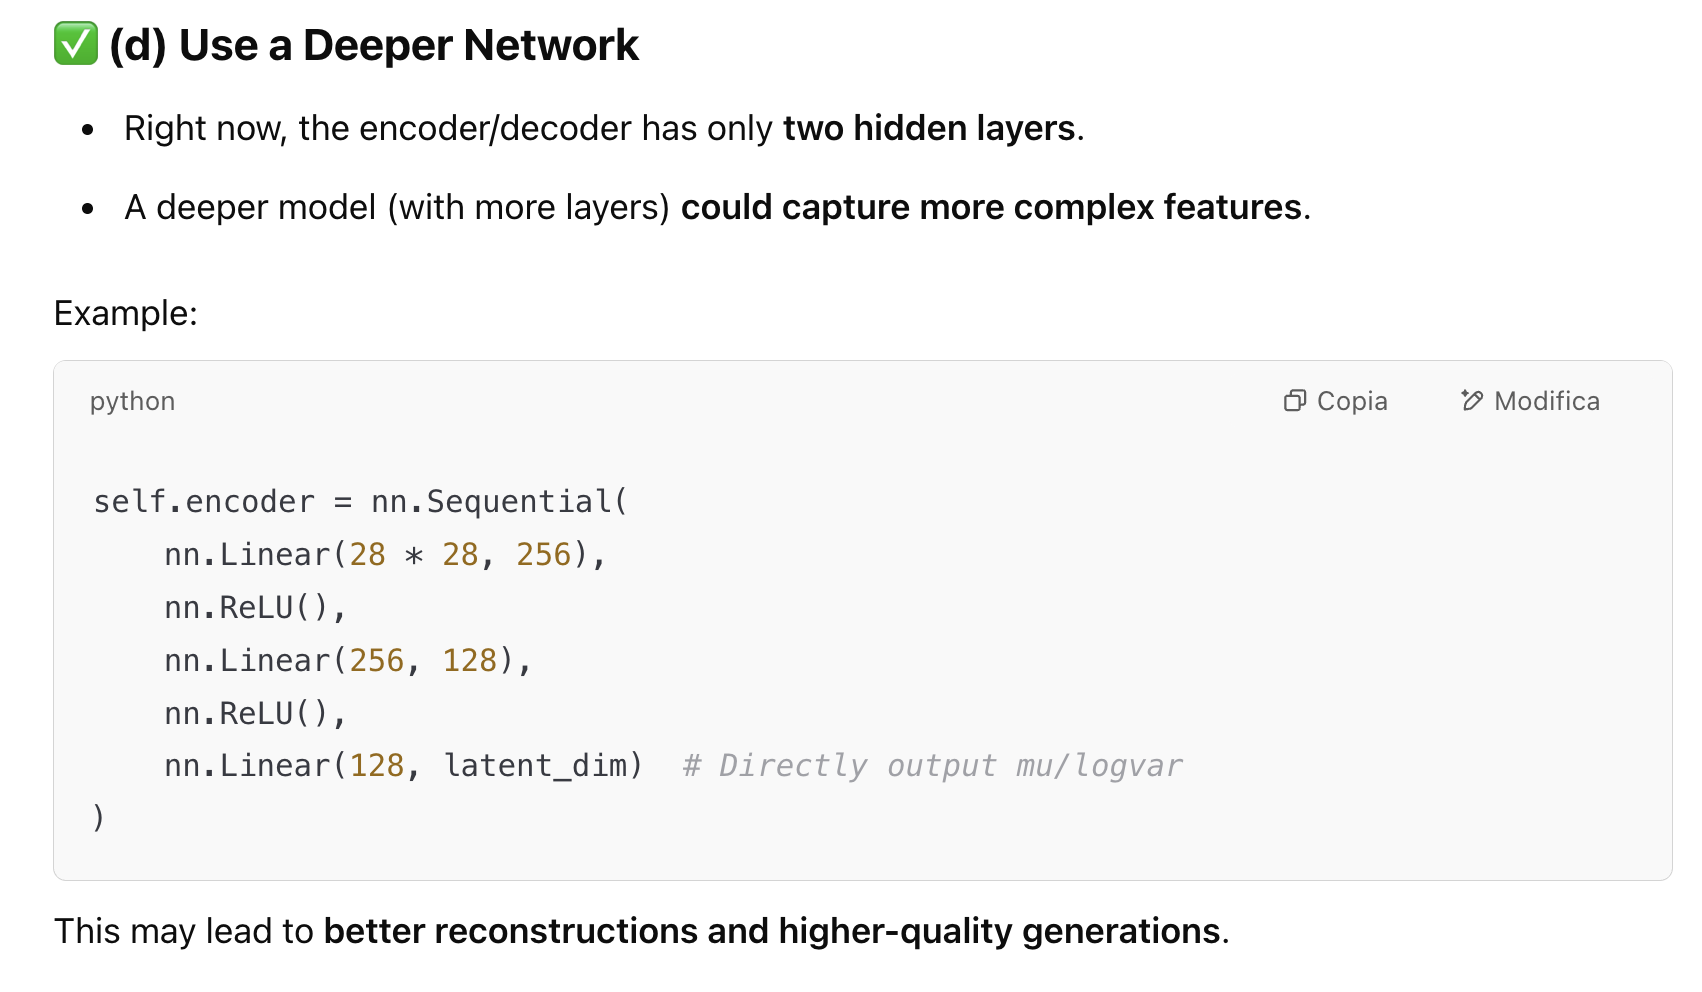

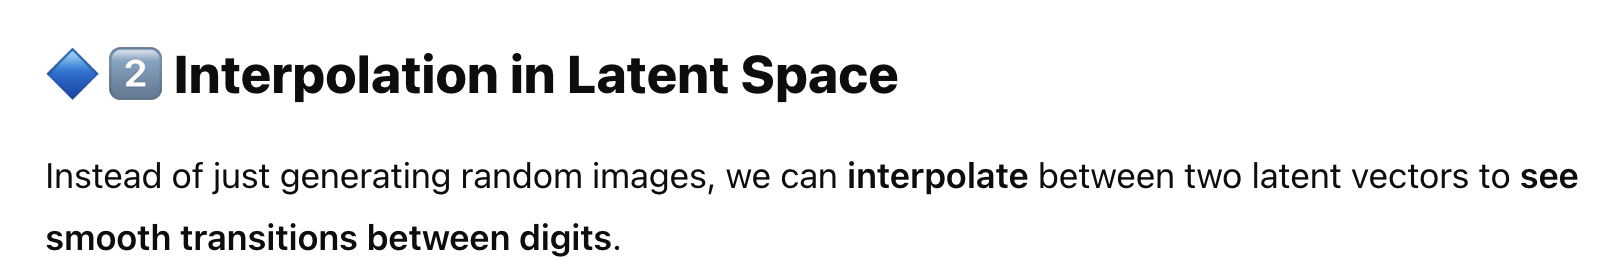

In [ ]:
z1 = torch.randn(1, latent_dim).to(device)
z2 = torch.randn(1, latent_dim).to(device)

interpolations = torch.linspace(0, 1, steps=10).to(device)  # 10-step interpolation
generated_images = []

for alpha in interpolations:
    z_interp = (1 - alpha) * z1 + alpha * z2  # Linear interpolation
    with torch.no_grad():
        generated_images.append(model.decoder(z_interp))

# Visualize the transition
fig, axes = plt.subplots(nrows=1, ncols=10, figsize=(10, 2))
for i, img in enumerate(generated_images):
    axes[i].imshow(img.cpu().numpy().reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.suptitle("Smooth Transition Between Two Latent Points")
plt.show()


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x16 and 26x64)

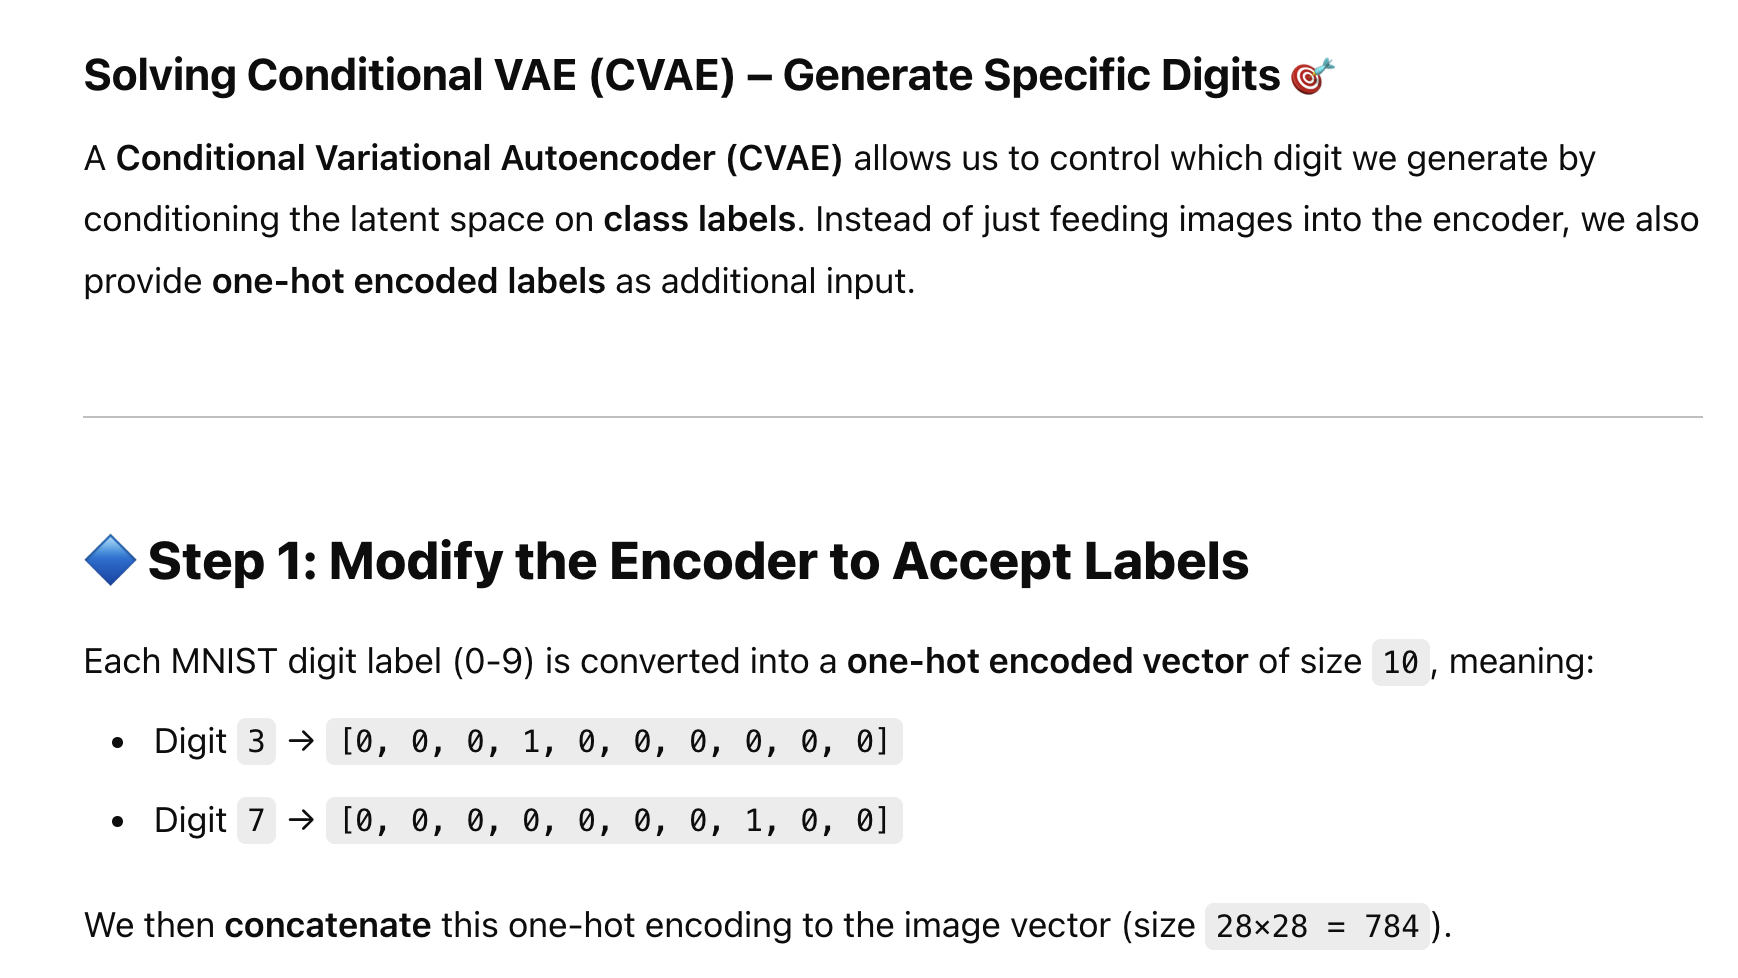

In [ ]:
import torch
from torch import nn

class CVAE(nn.Module):
    def __init__(self, latent_dim=9):
        super(CVAE, self).__init__()

        # Encoder: Now accepts concatenated input (image + label)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28 + 10, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Latent space - outputs mean (μ) and log variance (log σ²)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)

        # Decoder: Also takes (z + label) as input
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + 10, 64),   # Match last encoder layer
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 28 * 28),
            nn.Sigmoid()  # Final output is pixel-wise probability
        )

    # Reparameterization Trick (sampling from latent space)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std  # Sampled latent vector z

    # Forward pass (encoding + reparameterization + decoding)
    def forward(self, x, labels):
        # Concatenate image with one-hot label
        x = torch.cat((x, labels), dim=1)

        encoded = self.encoder(x)
        mu = self.fc_mu(encoded)
        logvar = self.fc_logvar(encoded)
        z = self.reparameterize(mu, logvar)

        # Concatenate latent vector with label before decoding
        z = torch.cat((z, labels), dim=1)
        decoded = self.decoder(z)
        return decoded, mu, logvar


In [ ]:
# Instantiate your model
model = CVAE(latent_dim=16)

# Total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# Trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 491,312
Trainable parameters: 491,312


In [ ]:
from torchsummary import summary
import torch
import torch.nn as nn

# Instantiate your model
model = CVAE(latent_dim=16)

# Move model to appropriate device (e.g., CPU for summary)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Input shape: image + label → [batch_size, 784 + 10]
input_size = (784 + 10,)  # one-hot label is 10-dimensional

# Print summary (forward only takes one input — the concatenated version)
summary(model.encoder, input_size=input_size)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]         203,520
              ReLU-2                  [-1, 256]               0
            Linear-3                  [-1, 128]          32,896
              ReLU-4                  [-1, 128]               0
            Linear-5                   [-1, 64]           8,256
              ReLU-6                   [-1, 64]               0
Total params: 244,672
Trainable params: 244,672
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.93
Estimated Total Size (MB): 0.94
----------------------------------------------------------------


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")



Total parameters: 491,312
Trainable parameters: 491,312


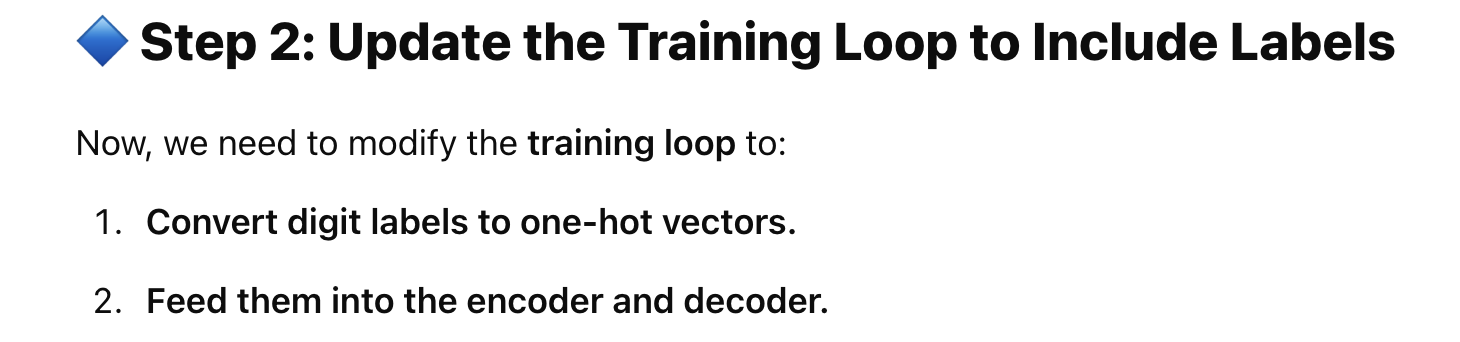


In [ ]:
import torch
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms

# Load MNIST dataset
tensor_transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True, download=True, transform=tensor_transform)
loader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)

# Set up model, optimizer, and device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 16
model = CVAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Function to one-hot encode labels
#https://pytorch.org/docs/stable/generated/torch.eye.html
def one_hot_encode(labels, num_classes=10):
    return torch.eye(num_classes)[labels].to(device)  # Converts labels to one-hot vectors

# loss function
def loss_function(recon_x, x, mu, logvar, beta=0.1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD

# Training loop
epochs = 50
model.train()
for epoch in range(epochs):
    train_loss = 0
    for images, labels in loader:
        images = images.view(-1, 28*28).to(device)  # Flatten images
        labels_one_hot = one_hot_encode(labels)  # Convert labels to one-hot

        optimizer.zero_grad()

        # Forward pass with labels
        recon_images, mu, logvar = model(images, labels_one_hot)

        # Compute ELBO loss
        loss = loss_function(recon_images, images, mu, logvar)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Average Loss: {train_loss / len(dataset):.4f}")

    # Save the model with a smart timestamped name
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")
model_name = f"Cvae_latent{latent_dim}_{timestamp}.pt"
torch.save(model.state_dict(), model_name)
print(f"✅ Model saved as '{model_name}'")


KeyboardInterrupt: 

In [ ]:
# Instantiate the same architecture with the same latent_dim
latent_dim = 16
model = CVAE(latent_dim).to(device)

# Load the saved state dictionary
model.load_state_dict(torch.load("/content/drive/MyDrive/Colab Notebooks/Models_24_25/Models/Cvae_latent16_2025-03-21_15-51.pt", map_location=device))

print("✅ Model loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/Models_24_25/Models/Cvae_latent16_2025-03-21_15-51.pt'

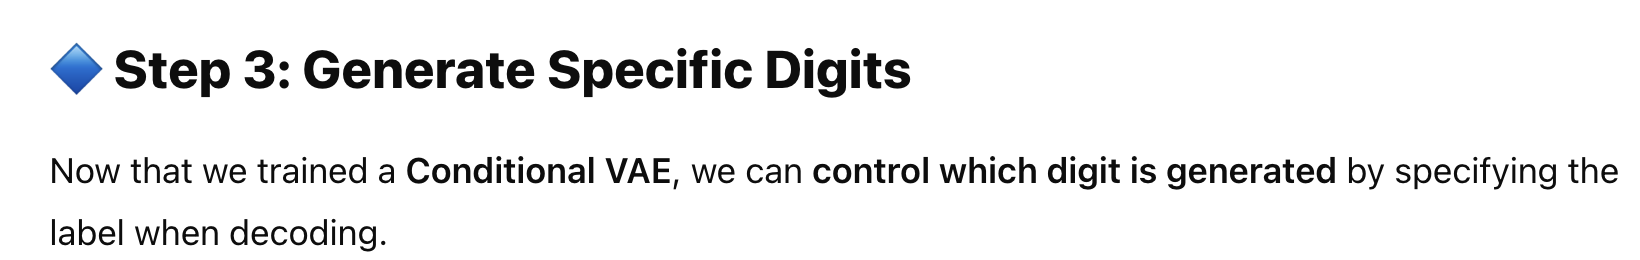

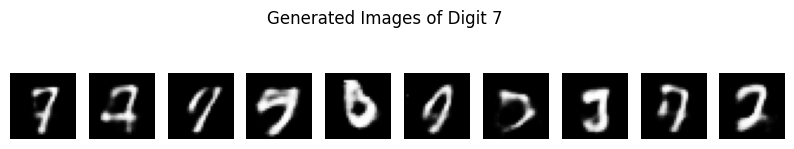

In [ ]:
import matplotlib.pyplot as plt

# Set model to evaluation mode
model.eval()

def one_hot_encode(labels, num_classes=10):
    return torch.eye(num_classes, device=labels.device)[labels]


# Function to generate images of a specific digit
def generate_digit(digit, num_samples=10):
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)  # Sample latent space
        labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)  # Label = digit
        labels_one_hot = one_hot_encode(labels)  # Convert label to one-hot
        z = torch.cat((z, labels_one_hot), dim=1)  # Concatenate z and label
        generated_images = model.decoder(z)  # Decode to image space

    return generated_images.cpu().numpy()

# Plot generated images for specific digits (e.g., "Only 3s")
digit_to_generate = 7
generated_images = generate_digit(digit_to_generate)

fig, axes = plt.subplots(nrows=1, ncols=10, figsize=(10, 2))
for i in range(10):
    axes[i].imshow(generated_images[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.suptitle(f"Generated Images of Digit {digit_to_generate}")
plt.show()


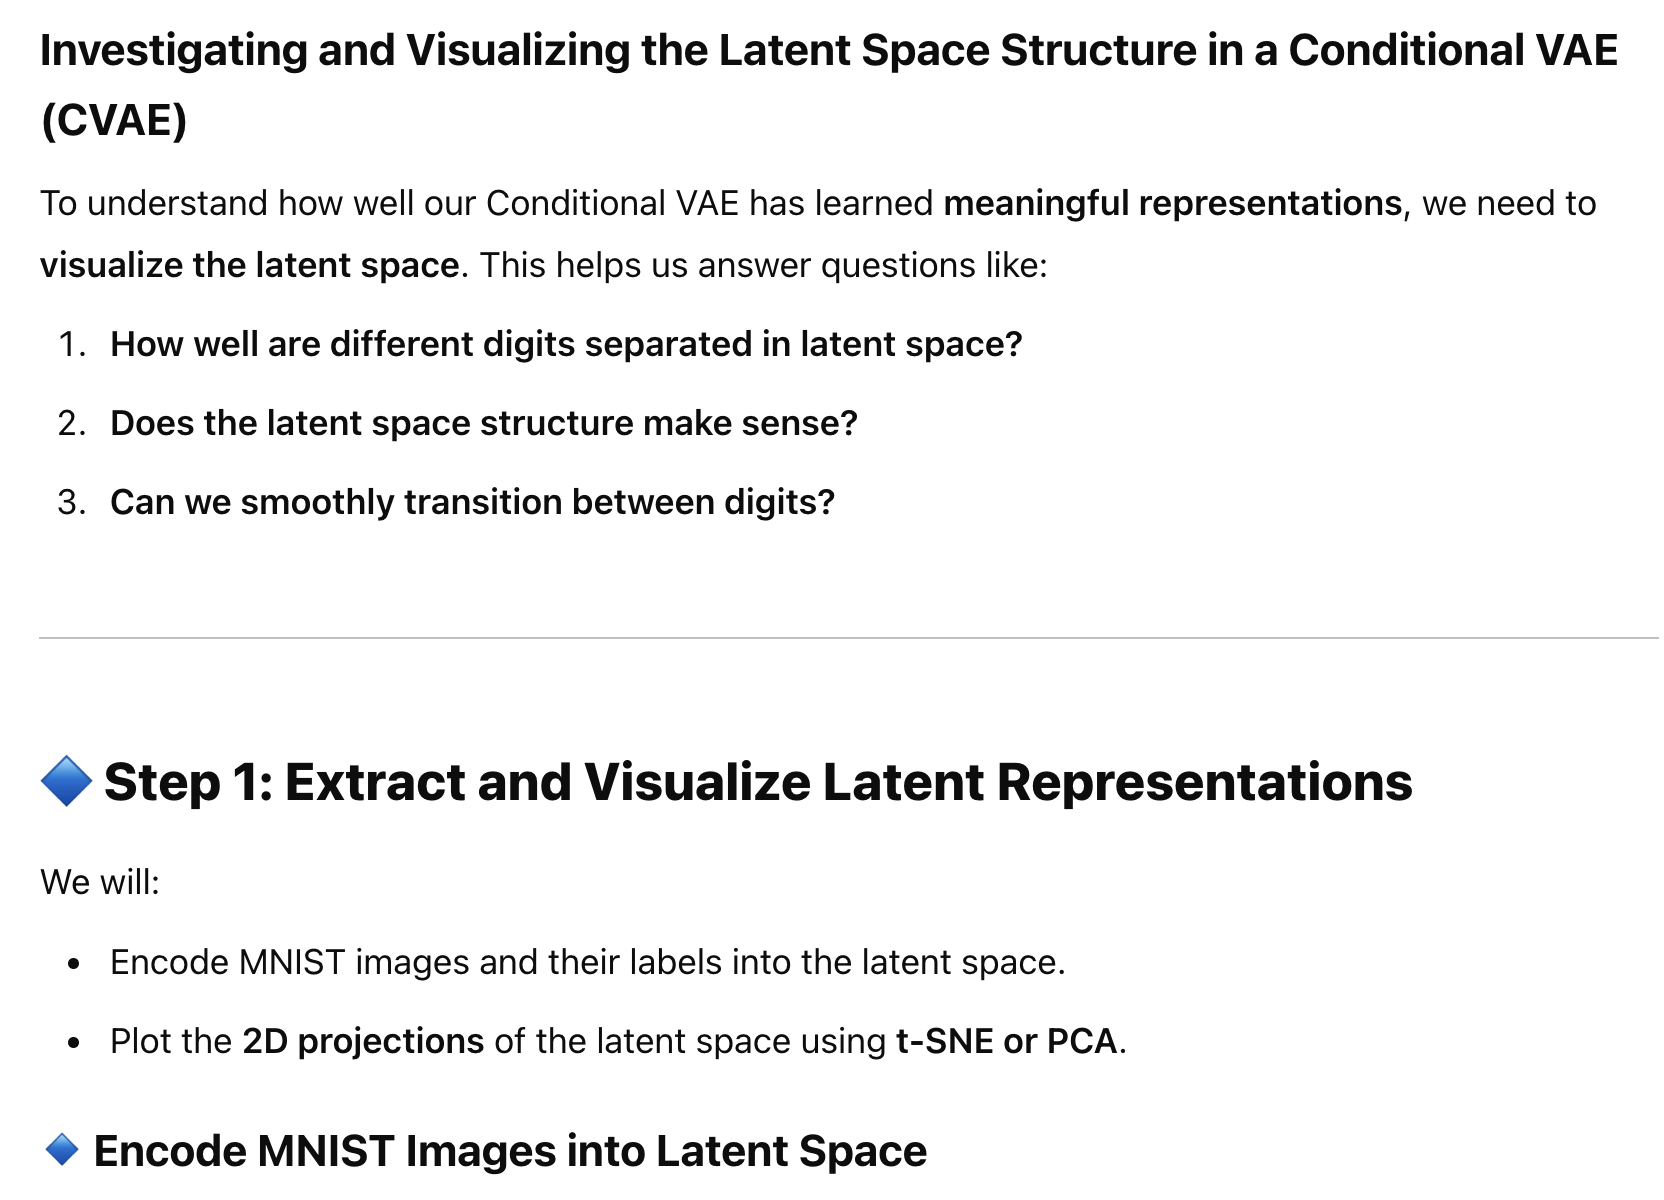

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def one_hot_encode(labels, num_classes=10):
    return torch.eye(num_classes, device=labels.device)[labels]


# Set model to evaluation mode
model.eval()

# Store latent vectors and labels
latent_vectors = []
labels_list = []

# Encode the entire dataset into the latent space
with torch.no_grad():
    for images, labels in loader:
        images = images.view(-1, 28*28).to(device)
        #labels_one_hot = one_hot_encode(labels)  # Convert labels to one-hot
        labels_one_hot = one_hot_encode(labels).to(device)  # Ensure on same device as images


        # Forward pass through encoder
        encoded = model.encoder(torch.cat((images, labels_one_hot), dim=1))
        mu = model.fc_mu(encoded)  # Extract mean latent vector

        # Store data
        latent_vectors.append(mu.cpu())
        labels_list.append(labels.cpu())

# Concatenate all latent vectors and labels into single tensors
latent_vectors = torch.cat(latent_vectors).numpy()
labels_list = torch.cat(labels_list).numpy()


In [ ]:
len(latent_vectors )

60000

In [ ]:
latent_vectors[100]

array([ 0.04677719, -0.07709785,  0.03162614,  0.3880073 ,  0.14216512,
        0.46558017, -0.08878556, -0.10810718, -1.3164016 ,  0.8169657 ,
       -0.25687423, -0.04615228, -0.1622799 , -0.06585524, -0.07164498,
       -0.01539929], dtype=float32)

In [ ]:
len(labels_list)

60000

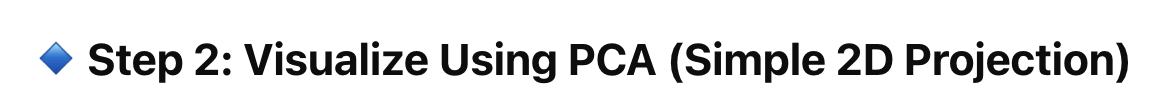

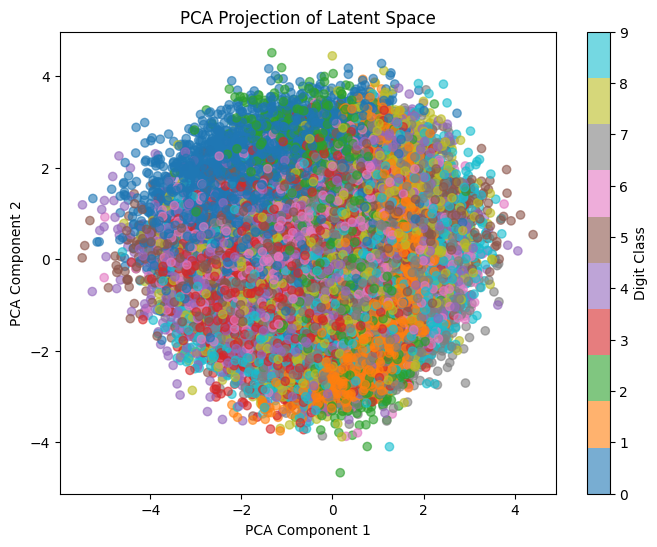

In [ ]:
# Reduce dimensionality of latent space (if latent_dim > 2)
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_vectors)

# Plot PCA results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=labels_list, cmap="tab10", alpha=0.6)
plt.colorbar(scatter, label="Digit Class")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of Latent Space")
plt.show()



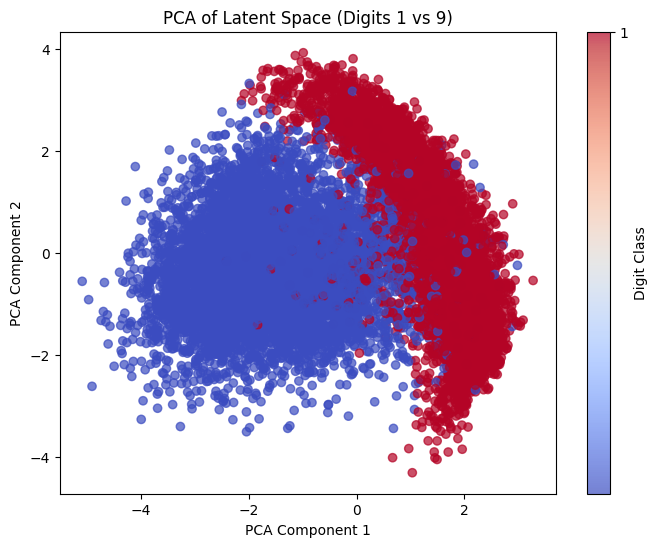

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Convert to NumPy if not already
latent_vectors = np.array(latent_vectors)
labels_list = np.array(labels_list)

# Select only digits 3 and 9
mask = np.isin(labels_list, [0, 1])
filtered_latents = latent_vectors[mask]
filtered_labels = labels_list[mask]

# Apply PCA
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(filtered_latents)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=filtered_labels, cmap="coolwarm", alpha=0.7)
plt.colorbar(scatter, ticks=[1, 9], label="Digit Class")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA of Latent Space (Digits 1 vs 9)")
plt.show()


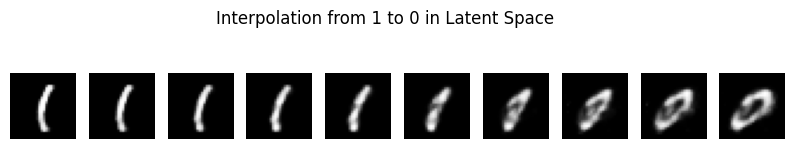

In [ ]:
import numpy as np

# Choose two random digit classes (e.g., 3 and 7)
digit_A, digit_B =1, 0

# Select two random latent vectors corresponding to these digits
idx_A = np.where(labels_list == digit_A)[0][0]
idx_B = np.where(labels_list == digit_B)[0][0]

z_A = latent_vectors[idx_A]
z_B = latent_vectors[idx_B]

# Generate interpolated latent vectors
interpolations = np.linspace(0, 1, num=10).reshape(-1, 1)  # 10-step interpolation
z_interpolated = z_A * (1 - interpolations) + z_B * interpolations
z_interpolated = torch.tensor(z_interpolated, dtype=torch.float32).to(device)

# Add labels (fixed as one-hot for digit_A)
labels_one_hot = one_hot_encode(torch.full((10,), digit_A, dtype=torch.long)).to(device)

# Decode interpolated vectors into images
with torch.no_grad():
    z_interpolated = torch.cat((z_interpolated, labels_one_hot), dim=1)  # Append labels
    generated_images = model.decoder(z_interpolated).cpu().numpy()

# Plot interpolated images
fig, axes = plt.subplots(1, 10, figsize=(10, 2))
for i in range(10):
    axes[i].imshow(generated_images[i].reshape(28, 28), cmap="gray")
    axes[i].axis("off")

plt.suptitle(f"Interpolation from {digit_A} to {digit_B} in Latent Space")
plt.show()


a challenge:  ["NVAE: A Deep Hierarchical Variational Autoencoder"](https://github.com/NVlabs/NVAE)....

Now we go to a more evolved 'convolutional' VAE on a bigger data set (CELEBA): see Lecture 8b on Convolution and "VAE_Convolution_CELEBA_5.ipynb".......

Next Lectur: **VQ-VAE**

[Neural Discrete Representation Learning](https://avdnoord.github.io/homepage/vqvae/)

https://arxiv.org/abs/1711.00937